In [ ]:
import pandas as pd
import re
import os
from pathlib import Path
import sys
import numpy as np
from tqdm import tqdm
import time
import matplotlib.pyplot as plt

project_root = Path.cwd().parent
sys.path.append(str(project_root))

from pyteomics import mgf, mass
from make_predictions.intensity_predictions import (
    obtain_predictions_pairs,
    safe_obtain_rt_predictions,
    safe_obtain_ccs_predictions,
)
from seq_utils.peptide import switch_random_il, get_proforma_bracketed
import metrics.metrics as M

from deeplc import DeepLC
from psm_utils.psm import PSM
from psm_utils.psm_list import PSMList
from seq_utils.peptide import has_il_outside_brackets


%matplotlib inline

In [2]:
# Load MaxQuant search results (same filtering as retention_time_il_swap.ipynb)
df = pd.read_csv("../temp_data/input_file.txt", sep="\t")
df = df[df["Sequence"].str.len() < 30]

# Parse modifications to ProForma format (for Koina API)
modification_dict_koina = {"(ox)": "UNIMOD:35", "(ac)": "UNIMOD:1", "(oxidation (m))": "UNIMOD:35", "(acetyl (protein n-term))": "UNIMOD:1"}
df["proforma_koina"] = df["Modified sequence"].apply(
    get_proforma_bracketed,
    before_aa=False, isalpha=True, isupper=True,
    pattern="\\([^()]*\\)|\\([^()]*\\([^()]*\\)[^()]*\\)",
    modification_dict=modification_dict_koina,
)

# Parse modifications to ProForma format (for DeepLC - uses modification names)
modification_dict_deeplc = {"(ox)": "Oxidation", "(ac)": "Acetyl", "(oxidation (m))": "Oxidation", "(acetyl (protein n-term))": "Acetyl"}
df["proforma_deeplc"] = df["Modified sequence"].apply(
    get_proforma_bracketed,
    before_aa=False, isalpha=True, isupper=True,
    pattern="\\([^()]*\\)|\\([^()]*\\([^()]*\\)[^()]*\\)",
    modification_dict=modification_dict_deeplc,
)

# Average retention times per unique peptide
merged_df = df.merge(
    df.groupby("proforma_deeplc")["Calibrated retention time"].mean(),
    on="proforma_deeplc", how="left", suffixes=('', '_mean')
)
merged_df = merged_df.drop_duplicates(subset="proforma_deeplc", keep="first")

# For fragment intensity: filter to unmodified, charge 2, with MS/MS scans
df_intensity = df[~df["proforma_koina"].str.contains(r"\[", na=False)].copy()
df_intensity = df_intensity[~np.isnan(df_intensity["MS/MS scan number"])]
df_intensity = df_intensity[df_intensity["Charge"] == 2]

peptides = np.array(df_intensity["proforma_koina"])
charges = np.array(df_intensity["Charge"])
peptides_switched = np.array([switch_random_il(p) for p in peptides])

print(f"Full dataset (for RT): {len(merged_df)} unique peptides")
print(f"Fragment intensity dataset (unmodified, charge 2): {len(df_intensity)} peptides")

C:\Users\robbi\AppData\Local\Temp\ipykernel_138700\1027923504.py:2: DtypeWarning: Columns (50) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../temp_data/input_file.txt", sep="\t")


Full dataset (for RT): 44227 unique peptides
Fragment intensity dataset (unmodified, charge 2): 121526 peptides


In [3]:
# Load MGF files
def parse_mgf(file_path):
    filename = os.path.splitext(os.path.basename(file_path))[0]
    spectra = {}
    with mgf.read(file_path) as reader:
        for spectrum in tqdm(reader):
            scan_str = spectrum.get("params", {})["title"].split(" scan=")[1].replace("\"", "")
            scan_number = int(scan_str) if scan_str else 0
            spectra[scan_number] = {
                'm/z array': spectrum.get('m/z array', []),
                'intensity array': spectrum.get('intensity array', [])
            }
    return {filename: spectra}

files = [
    "../temp_data/LFQ_Orbitrap_DDA_Condition_A_Sample_Alpha_01.mgf",
    "../temp_data/LFQ_Orbitrap_DDA_Condition_A_Sample_Alpha_02.mgf",
    "../temp_data/LFQ_Orbitrap_DDA_Condition_A_Sample_Alpha_03.mgf",
    "../temp_data/LFQ_Orbitrap_DDA_Condition_B_Sample_Alpha_01.mgf",
    "../temp_data/LFQ_Orbitrap_DDA_Condition_B_Sample_Alpha_02.mgf",
    "../temp_data/LFQ_Orbitrap_DDA_Condition_B_Sample_Alpha_03.mgf",
]

mgf_dict = {}
for f in files:
    mgf_dict.update(parse_mgf(f))

100%|██████████| 109507/109507 [00:12<00:00, 8520.79it/s] 

100%|██████████| 111413/111413 [00:14<00:00, 7592.75it/s] 

100%|██████████| 117880/117880 [00:15<00:00, 7561.07it/s] 

100%|██████████| 111088/111088 [00:13<00:00, 8506.46it/s] 

100%|██████████| 114818/114818 [00:18<00:00, 6327.95it/s]

100%|██████████| 118174/118174 [00:25<00:00, 4719.33it/s] 


In [4]:
# Load or generate fragment intensity predictions
peptides_switch_predictions_f = "../temp_data/peptides_switch_predictions_puyvelde.csv"
peptides_predictions_f = "../temp_data/peptides_predictions_puyvelde.csv"

def safe_obtain_predictions(peptides_batch, switched, charges, max_retries=3):
    for attempt in range(max_retries):
        try:
            return obtain_predictions_pairs(peptides_batch, switched=switched, 
                                            model="AlphaPeptDeep_ms2_generic", 
                                            charges=charges, collision_energies=27)
        except Exception as e:
            if attempt < max_retries - 1:
                time.sleep(1)
            else:
                raise RuntimeError(f"Prediction failed after {max_retries} attempts.") from e

if os.path.exists(peptides_switch_predictions_f) and os.path.exists(peptides_predictions_f):
    peptides_switch_predictions = pd.read_csv(peptides_switch_predictions_f)
    peptides_predictions = pd.read_csv(peptides_predictions_f)
else:
    batch_size = 5000
    peptides_switch_predictions_list, peptides_predictions_list = [], []
    for i in tqdm(range(0, len(peptides), batch_size)):
        batch, batch_switched = peptides[i:i+batch_size], peptides_switched[i:i+batch_size]
        batch_charges = charges[i:i+batch_size]
        peptides_switch_predictions_list.append(safe_obtain_predictions(batch_switched, True, batch_charges))
        peptides_predictions_list.append(safe_obtain_predictions(batch, False, batch_charges))
    
    peptides_switch_predictions = pd.concat(peptides_switch_predictions_list, ignore_index=True)
    peptides_predictions = pd.concat(peptides_predictions_list, ignore_index=True)
    peptides_switch_predictions.to_csv(peptides_switch_predictions_f, index=False)
    peptides_predictions.to_csv(peptides_predictions_f, index=False)

# Create lookup dictionaries
dict_predictions = dict(tuple(peptides_predictions.groupby("peptide_sequences")))
dict_predictions_switched = dict(tuple(peptides_switch_predictions.groupby("peptide_sequences")))

In [5]:
# Spectrum annotation and matching functions
def get_theoretical_fragments(peptide_sequence, max_charge=2):
    clean_seq = re.sub(r'\[.*?\]', '', peptide_sequence)
    fragments = []
    seq_len = len(clean_seq)
    for i in range(1, seq_len):
        for z in range(1, max_charge + 1):
            try:
                fragments.append({'ion': f"b{i}", 'charge': z, 'mz': mass.fast_mass(clean_seq[:i], ion_type='b', charge=z)})
            except: pass
            try:
                fragments.append({'ion': f"y{seq_len-i}", 'charge': z, 'mz': mass.fast_mass(clean_seq[i:], ion_type='y', charge=z)})
            except: pass
    return fragments

def annotate_spectrum(mz_array, intensity_array, peptide_sequence, charge, tol_ppm=20):
    mz_array, intensity_array = np.array(mz_array, dtype=np.float64), np.array(intensity_array, dtype=np.float64)
    matched, used_peaks = [], set()
    for frag in get_theoretical_fragments(peptide_sequence, max_charge=charge):
        mz_diff = np.abs((mz_array - frag['mz']) / frag['mz'] * 1e6)
        matches = np.where(mz_diff < tol_ppm)[0]
        if len(matches) > 0:
            best_idx = matches[np.argmin(mz_diff[matches])]
            if best_idx not in used_peaks:
                used_peaks.add(best_idx)
                matched.append({'ion': frag['ion'], 'charge': frag['charge'], 'intensity': intensity_array[best_idx]})
    return pd.DataFrame(matched)

# Match observed spectra to predictions (using df_intensity)
dict_orig_to_swap = dict(zip(peptides, peptides_switched))
dict_il_intensity = {}
for idx, row in tqdm(df_intensity.iterrows(), total=len(df_intensity), desc="Processing"):
    mz_array = mgf_dict[row["Raw file"]][int(row['MS/MS scan number'])]["m/z array"]
    intensity_array = mgf_dict[row["Raw file"]][int(row['MS/MS scan number'])]['intensity array']
    
    df_annotation = annotate_spectrum(mz_array, intensity_array, row['proforma_koina'], row['Charge'])
    if df_annotation.empty:
        continue

    swap_sequence = dict_orig_to_swap.get(row['proforma_koina'])
    sub_df_pred = dict_predictions.get(row['proforma_koina'])
    sub_df_pred_sw = dict_predictions_switched.get(swap_sequence) if swap_sequence else None
    if sub_df_pred is None or sub_df_pred_sw is None:
        continue

    # Parse prediction annotations
    sub_df_pred = sub_df_pred.copy()
    sub_df_pred_sw = sub_df_pred_sw.copy()
    sub_df_pred[['ion', 'charge']] = sub_df_pred['annotation'].str.extract(r"([a-zA-Z]+\d+)\+(\d+)")
    sub_df_pred['charge'] = sub_df_pred['charge'].astype(int)
    sub_df_pred_sw[['ion', 'charge']] = sub_df_pred_sw['annotation'].str.extract(r"([a-zA-Z]+\d+)\+(\d+)")
    sub_df_pred_sw['charge'] = sub_df_pred_sw['charge'].astype(int)
    df_annotation['charge'] = df_annotation['charge'].astype(int)

    # Merge observed with predictions
    merged = pd.merge(df_annotation, sub_df_pred, on=['ion', 'charge'], how='inner')
    merged_all = pd.merge(merged, sub_df_pred_sw, on=['ion', 'charge'], how='inner').drop_duplicates()
    
    if merged_all.empty or max(merged_all["intensity"].values) == 0:
        continue
        
    max_int = max(merged_all["intensity"].values)
    dict_il_intensity[row['proforma_koina']] = {
        "intensity_obs_norm": merged_all["intensity"].values / max_int,
        "intensities_orig": merged_all["intensities_x"].values,
        "intensities_swapped": merged_all["intensities_y"].values,
        "mz_orig": merged_all["mz_x"].values,
    }

Processing: 100%|██████████| 121526/121526 [07:07<00:00, 284.31it/s]


In [6]:
# Score all peptides with all metrics
metric_keys = [
    "mse", "pearson_correlation", "spearman_correlation", "dot_product",
    "mara_similarity", "modified_dot_product", "massbank_score", "gnps_score",
    "stein_scott_score", "wasserstein", "kendall_tau", "mutual_information",
    "bray_curtis", "canberra_distance", "mara_weighted_similarity", "diagnostic_weighted_similarity",
]

scored_dict_seqs = {}
for seq, frag in tqdm(dict_il_intensity.items()):
    score_dict = {}
    inp_base = {"mz1": frag["mz_orig"], "mz2": frag["mz_orig"], 
                "diagnostic_mz": np.array([]), "mz": max(frag["mz_orig"])}
    
    for key in metric_keys:
        try:
            score = getattr(M, key)(intensity1=frag["intensity_obs_norm"], intensity2=frag["intensities_orig"], **inp_base)
        except: score = np.nan
        try:
            score_sw = getattr(M, key)(intensity1=frag["intensity_obs_norm"], intensity2=frag["intensities_swapped"], **inp_base)
        except: score_sw = np.nan
        score_dict[f"{key}|orig"], score_dict[f"{key}|swapped"] = score, score_sw
    
    scored_dict_seqs[seq] = score_dict

scored_df_seqs = pd.DataFrame(scored_dict_seqs).T

  0%|          | 0/30609 [00:00<?, ?it/s]c:\Users\robbi\OneDrive\Documents\GitHub\spectral_similarity\metrics\metrics.py:24: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = pearsonr(intensity1, intensity2)
c:\Users\robbi\OneDrive\Documents\GitHub\spectral_similarity\metrics\metrics.py:30: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = spearmanr(intensity1, intensity2)
c:\Users\robbi\OneDrive\Documents\GitHub\spectral_similarity\metrics\metrics.py:24: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = pearsonr(intensity1, intensity2)
c:\Users\robbi\OneDrive\Documents\GitHub\spectral_similarity\metrics\metrics.py:30: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = spearmanr(intensity1, intensity2)
  9%|▉         | 2716/30609 [00:06<01:03, 440.70it/s]c:\Users\rob

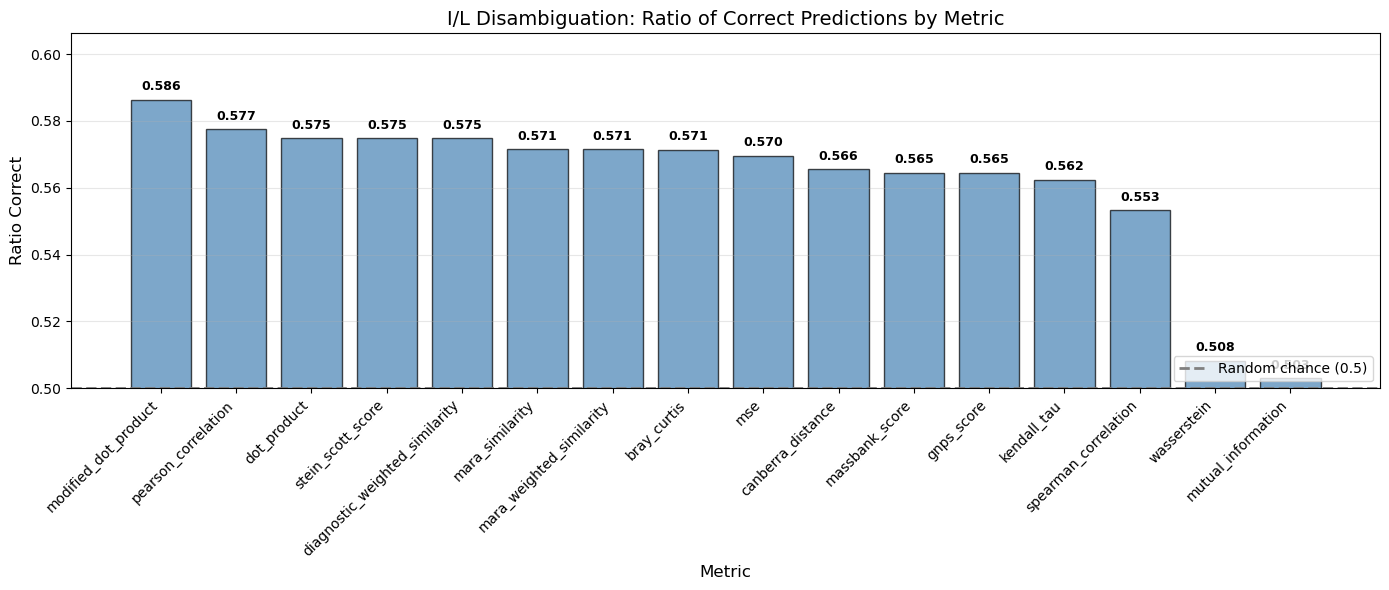

: 

In [ ]:
# Calculate ratio correct for each metric (flip values < 0.5)
ratio_correct_dict = {}
for metric_key in metric_keys:
    diff = scored_df_seqs[f"{metric_key}|orig"] - scored_df_seqs[f"{metric_key}|swapped"]
    positive, negative = (diff > 0).sum(), (diff < 0).sum()
    ratio = positive / (positive + negative) if (positive + negative) > 0 else 0.0
    ratio_correct_dict[metric_key] = 1.0 - ratio if ratio < 0.5 else ratio

# Sort and plot
metrics_sorted = sorted(ratio_correct_dict.keys(), key=lambda x: ratio_correct_dict[x], reverse=True)
values_sorted = [ratio_correct_dict[m] for m in metrics_sorted]

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.bar(range(len(metrics_sorted)), values_sorted, color='steelblue', edgecolor='black', alpha=0.7)

for bar, val in zip(bars, values_sorted):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002, 
            f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.axhline(y=0.5, color='gray', linestyle='--', linewidth=2, label='Random chance (0.5)')
ax.legend(loc='lower right')
ax.set_xticks(range(len(metrics_sorted)))
ax.set_xticklabels(metrics_sorted, rotation=45, ha='right', fontsize=10)
ax.set_ylabel('Ratio Correct', fontsize=12)
ax.set_xlabel('Metric', fontsize=12)
ax.set_title('I/L Disambiguation: Ratio of Correct Predictions by Metric', fontsize=14)
ax.set_ylim([0.5, max(values_sorted) + 0.02])
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig("../temp_data/metrics_ratio_correct_bargraph.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Train/eval split (10% for calibration, 90% for evaluation)
df_train = merged_df.sample(frac=0.1, random_state=42)
df_eval = merged_df.drop(df_train.index)

# Build PSM lists
psm_list_train = PSMList(psm_list=[
    PSM(peptidoform=row["proforma_deeplc"], retention_time=row["Calibrated retention time_mean"], spectrum_id=idx)
    for idx, row in df_train.iterrows()
])
psm_list_eval = PSMList(psm_list=[
    PSM(peptidoform=row["proforma_deeplc"], retention_time=row["Calibrated retention time_mean"], spectrum_id=idx)
    for idx, row in df_eval.iterrows()
])
psm_list_eval_swapped = PSMList(psm_list=[
    PSM(peptidoform=switch_random_il(row["proforma_deeplc"]), retention_time=row["Calibrated retention time_mean"], spectrum_id=idx)
    for idx, row in df_eval.iterrows()
])

# Train DeepLC and make predictions
dlc = DeepLC(deeplc_retrain=False, n_epochs=20)
dlc.calibrate_preds(psm_list_train)
preds = dlc.make_preds(psm_list=psm_list_eval)
preds_swapped = dlc.make_preds(psm_list=psm_list_eval_swapped)

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 89ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 89ms/step
 1/39 ━━━━━━━━━━━━━━━━━━━━ 7s 199ms/stepWARNING:tensorflow:5 out of the last 11 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x00000287D0500860> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
29/39 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step

In [ ]:
# Calculate RT ratio correct (matching retention_time_il_swap.ipynb methodology)
df_eval = df_eval.copy()
df_eval["predicted_rt"] = preds
df_eval["predicted_rt_swapped"] = preds_swapped

# Compute absolute differences on full eval set
diff_original = (df_eval["predicted_rt"] - df_eval["Calibrated retention time_mean"]).abs()
diff_swapped = (df_eval["predicted_rt_swapped"] - df_eval["Calibrated retention time_mean"]).abs()

# Create label column (using <= like retention_time_il_swap.ipynb)
df_eval["chosen_label"] = np.where(diff_original <= diff_swapped, "original", "swapped")

# NOW filter to peptides with I/L outside brackets
df_eval_il = df_eval[df_eval["proforma_deeplc"].apply(has_il_outside_brackets)].copy()

# Calculate ratio correct
rt_correct = (df_eval_il["chosen_label"] == "original").sum()
rt_total = len(df_eval_il)
rt_ratio = rt_correct / rt_total if rt_total > 0 else 0.5
rt_ratio = 1.0 - rt_ratio if rt_ratio < 0.5 else rt_ratio
print(f"Retention Time (DeepLC calibrated) - Ratio Correct: {rt_ratio:.4f} ({rt_correct}/{rt_total})")

Retention Time (DeepLC calibrated) - Ratio Correct: 0.6403 (22735/35506)


In [ ]:
# ============================================================================
# CCS (Collision Cross Section) PREDICTIONS (using Koina API)
# ============================================================================

# Get unique peptides with I/L for CCS prediction (use same merged_df as RT)
df_ccs = merged_df[merged_df["proforma_koina"].apply(has_il_outside_brackets)].copy()

# Get peptides and their I/L swapped versions
ccs_peptides = df_ccs["proforma_koina"].values
ccs_peptides_switched = np.array([switch_random_il(p) for p in ccs_peptides])
ccs_charges = np.array([2] * len(ccs_peptides))  # Default charge 2

print(f"CCS prediction set: {len(ccs_peptides)} unique peptides with I/L")

# Load or generate CCS predictions
ccs_predictions_f = "../temp_data/ccs_predictions_full.csv"
ccs_predictions_sw_f = "../temp_data/ccs_predictions_sw_full.csv"

if os.path.exists(ccs_predictions_f) and os.path.exists(ccs_predictions_sw_f):
    ccs_predictions = pd.read_csv(ccs_predictions_f)
    ccs_predictions_sw = pd.read_csv(ccs_predictions_sw_f)
    print("Loaded cached CCS predictions")
else:
    # Batch predictions
    batch_size = 5000
    ccs_pred_list, ccs_pred_sw_list = [], []
    for i in tqdm(range(0, len(ccs_peptides), batch_size), desc="CCS Predictions"):
        batch = ccs_peptides[i:i+batch_size]
        batch_sw = ccs_peptides_switched[i:i+batch_size]
        batch_charges = ccs_charges[i:i+batch_size]
        
        ccs_pred_list.append(safe_obtain_ccs_predictions(batch, switched=False, charges=batch_charges))
        ccs_pred_sw_list.append(safe_obtain_ccs_predictions(batch_sw, switched=True, charges=batch_charges))
    
    ccs_predictions = pd.concat(ccs_pred_list, ignore_index=True)
    ccs_predictions_sw = pd.concat(ccs_pred_sw_list, ignore_index=True)
    ccs_predictions.to_csv(ccs_predictions_f, index=False)
    ccs_predictions_sw.to_csv(ccs_predictions_sw_f, index=False)
    print("Generated and saved CCS predictions")

CCS prediction set: 39461 unique peptides with I/L


CCS Predictions:   0%|          | 0/8 [00:00<?, ?it/s]

CCS prediction input shape: (5000, 2)


AlphaPept_ccs_generic::   0%|          | 0/5 [00:00<?, ?it/s]

CCS prediction input shape: (5000, 2)


...

AlphaPept_ccs_generic::   0%|          | 0/5 [00:00<?, ?it/s]

CCS prediction input shape: (4461, 2)


AlphaPept_ccs_generic::   0%|          | 0/5 [00:00<?, ?it/s]

CCS Predictions: 100%|██████████| 8/8 [00:11<00:00,  1.44s/it]

Generated and saved CCS predictions


In [ ]:
# Calculate CCS discriminative power
# Create lookup dictionaries for CCS predictions
ccs_dict = dict(zip(ccs_predictions["peptide_sequences"], ccs_predictions["ccs"]))
ccs_sw_dict = dict(zip(ccs_predictions_sw["peptide_sequences"], ccs_predictions_sw["ccs"]))

# For each original peptide, check if CCS predictions differ
ccs_results = []
for orig_seq, sw_seq in zip(ccs_peptides, ccs_peptides_switched):
    pred_ccs = ccs_dict.get(orig_seq)
    pred_ccs_sw = ccs_sw_dict.get(sw_seq)
    
    if pred_ccs is not None and pred_ccs_sw is not None:
        diff = abs(pred_ccs - pred_ccs_sw)
        ccs_results.append({
            "original_seq": orig_seq,
            "swapped_seq": sw_seq,
            "ccs_original": pred_ccs,
            "ccs_swapped": pred_ccs_sw,
            "diff": diff
        })

ccs_df = pd.DataFrame(ccs_results)

# Show CCS statistics
print(f"Mean CCS value: {ccs_df['ccs_original'].mean():.2f} Å²")
print(f"Mean CCS difference (I vs L): {ccs_df['diff'].mean():.4f} Å²")
print(f"Relative difference: {(ccs_df['diff'].mean() / ccs_df['ccs_original'].mean() * 100):.4f}%")

Mean CCS value: 420.18 Å²
Mean CCS difference (I vs L): 1.3534 Å²
Relative difference: 0.3221%

CCS discriminative power: 0.8366 (33014/39461)
(% of peptides where CCS predictions differ by >0.1%)

Note: CCS 'ratio correct' cannot be calculated without observed CCS values.


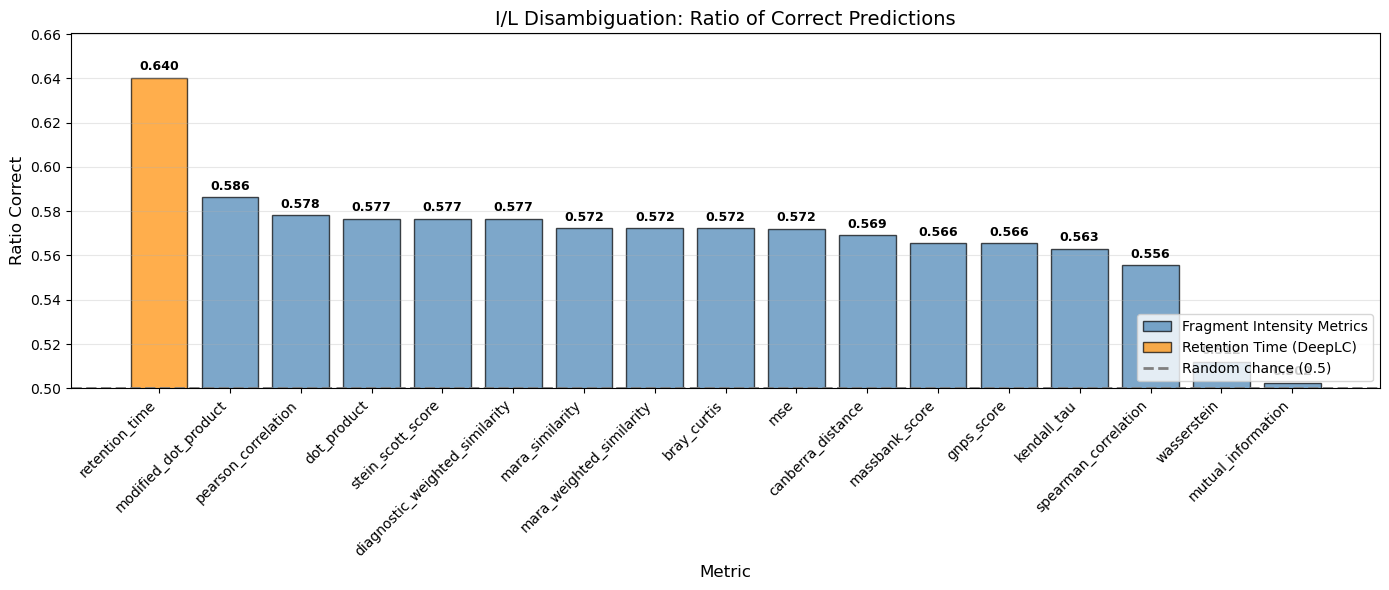


Note: CCS excluded from comparison - no observed CCS values available to calculate ratio correct.
CCS discriminative power (model predicts different values): 83.66%


In [ ]:
# ============================================================================
# Combined Bar Plot: Fragment Intensity Metrics + Retention Time
# (CCS excluded - no observed values to calculate ratio correct)
# ============================================================================

# Collect all results
all_ratios = ratio_correct_dict.copy()
all_ratios["retention_time"] = rt_ratio

# Sort and plot
all_sorted = sorted(all_ratios.keys(), key=lambda x: all_ratios[x], reverse=True)
all_values = [all_ratios[m] for m in all_sorted]

fig, ax = plt.subplots(figsize=(14, 6))

# Color RT differently
colors = ['darkorange' if m == 'retention_time' else 'steelblue' for m in all_sorted]
bars = ax.bar(range(len(all_sorted)), all_values, color=colors, edgecolor='black', alpha=0.7)

for bar, val in zip(bars, all_values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002, 
            f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='steelblue', edgecolor='black', alpha=0.7, label='Fragment Intensity Metrics'),
    Patch(facecolor='darkorange', edgecolor='black', alpha=0.7, label='Retention Time (DeepLC)'),
    plt.Line2D([0], [0], color='gray', linestyle='--', linewidth=2, label='Random chance (0.5)')
]
ax.legend(handles=legend_elements, loc='top right')

ax.set_xticks(range(len(all_sorted)))
ax.set_xticklabels(all_sorted, rotation=45, ha='right', fontsize=10)
ax.set_ylabel('Ratio Correct', fontsize=12)
ax.set_xlabel('Metric', fontsize=12)
ax.set_title('I/L Disambiguation: Ratio of Correct Predictions', fontsize=14)
ax.set_ylim([0.5, max(all_values) + 0.02])
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig("../temp_data/all_metrics_ratio_correct_bargraph.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Print summary
print("I/L Disambiguation Results Summary:")
print("=" * 50)
for m, v in zip(all_sorted, all_values):
    label = "(RT)" if m == "retention_time" else ""
    print(f"{m:35s}: {v:.4f} {label}")

I/L Disambiguation Results Summary:
retention_time                     : 0.6403 (RT)
modified_dot_product               : 0.5863 
pearson_correlation                : 0.5781 
dot_product                        : 0.5766 
stein_scott_score                  : 0.5765 
diagnostic_weighted_similarity     : 0.5765 
mara_similarity                    : 0.5724 
mara_weighted_similarity           : 0.5724 
bray_curtis                        : 0.5723 
mse                                : 0.5720 
canberra_distance                  : 0.5691 
massbank_score                     : 0.5655 
gnps_score                         : 0.5655 
kendall_tau                        : 0.5630 
spearman_correlation               : 0.5556 
wasserstein                        : 0.5119 
mutual_information                 : 0.5025 
